In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================
df = pd.read_csv("Dataset_coolingwater.csv")

print("="*60)
print("INFORMASI DATASET")
print("="*60)
print(df.info())

print("\nJumlah data tiap kelas:")
print(df["Target"].value_counts())

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pH              1056 non-null   float64
 1   SC              1056 non-null   int64  
 2   Nitrite         1056 non-null   int64  
 3   Fe              1056 non-null   float64
 4   Sulfate         1056 non-null   int64  
 5   Turbidity       1056 non-null   float64
 6   Target          1056 non-null   object 
 7   Target_encoded  1056 non-null   int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 66.1+ KB
None

Jumlah data tiap kelas:
Target
Layak          958
Tidak Layak     98
Name: count, dtype: int64


In [3]:
# ============================================================
# PREPROCESSING DATA
# ============================================================

print("="*60)
print("PREPROCESSING DATA")
print("="*60)

# Cek missing values
print("Missing Values:")
print(df.isnull().sum())

# Cek data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# PERBAIKAN: Cek jumlah data SEBELUM drop duplikat
print("\nJumlah data sebelum hapus duplikat:", len(df))

duplikat = df[df.duplicated()]

print("\nData Duplikat:")
print(duplikat)

PREPROCESSING DATA
Missing Values:
pH                0
SC                0
Nitrite           0
Fe                0
Sulfate           0
Turbidity         0
Target            0
Target_encoded    0
dtype: int64

Jumlah data duplikat: 10

Jumlah data sebelum hapus duplikat: 1056

Data Duplikat:
       pH    SC  Nitrite    Fe  Sulfate  Turbidity Target  Target_encoded
108  9.47  1648     1072  0.77       32       28.0  Layak               1
140  9.23  4822     1213  0.35       25       25.0  Layak               1
151  9.22  4750     1064  0.42       36       23.0  Layak               1
158  9.44  4784     1112  0.76       24       25.0  Layak               1
214  9.27  4522     1022  0.21       14       18.6  Layak               1
215  9.27  4522     1022  0.21       14       18.6  Layak               1
234  9.44  4784     1112  0.76       24       25.0  Layak               1
246  8.92  1770     1109  0.52       29       26.0  Layak               1
257  8.18  4726     1211  0.11       13   

In [4]:
# Hapus data duplikat
df = df.drop_duplicates()

print("Jumlah data setelah hapus duplikat :", len(df))

Jumlah data setelah hapus duplikat : 1046


In [6]:
# ============================================================
# PEMISAHAN FITUR DAN TARGET
# ============================================================
X = df.drop(["Target", "Target_encoded"], axis=1)
y = df["Target_encoded"]

print("\nFitur yang digunakan:")
print(X.columns.tolist())


Fitur yang digunakan:
['pH', 'SC', 'Nitrite', 'Fe', 'Sulfate', 'Turbidity']


In [7]:
# ============================================================
# SPLIT DATA TRAINING DAN TESTING
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("\n" + "="*60)
print("UKURAN DATA")
print("="*60)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)


UKURAN DATA
X_train : (732, 6)
X_test  : (314, 6)


In [14]:
# ============================================================
# MODEL AWAL RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# ============================================================
# CROSS VALIDATION
# ============================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=skf,
    scoring='f1'
)

print("\n" + "="*60)
print("HASIL CROSS VALIDATION")
print("="*60)
print("F1-Score tiap fold:")
print(cv_scores)

print("\nRata-rata F1-Score:")
print(cv_scores.mean())


HASIL CROSS VALIDATION
F1-Score tiap fold:
[1.         0.99625468 1.         1.         0.99622642]

Rata-rata F1-Score:
0.9984962193484559


In [ ]:
# ============================================================
# TRAIN MODEL
# ============================================================
rf.fit(X_train, y_train)

# ============================================================
# PREDIKSI
# ============================================================
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# ============================================================
# EVALUASI MODEL
# ============================================================
print("\n" + "="*60)
print("EVALUASI MODEL")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


EVALUASI MODEL
Accuracy : 0.9968152866242038
ROC-AUC  : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       1.00      1.00      1.00       285

    accuracy                           1.00       314
   macro avg       1.00      0.98      0.99       314
weighted avg       1.00      1.00      1.00       314



CONFUSION MATRIX
[[ 28   1]
 [  0 285]]


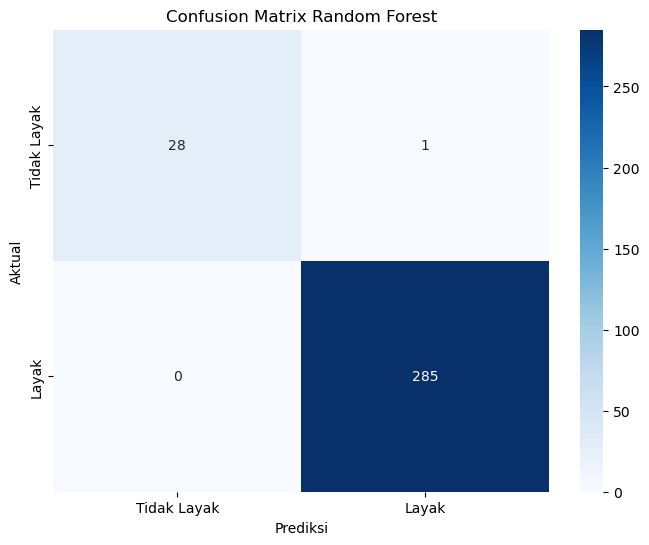

In [16]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("="*50)
print("CONFUSION MATRIX")
print("="*50)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Layak', 'Layak'],
    yticklabels=['Tidak Layak', 'Layak']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")
plt.show()


Feature Importance:
     Feature  Importance
3         Fe    0.562844
5  Turbidity    0.232631
0         pH    0.069179
2    Nitrite    0.067635
1         SC    0.044390
4    Sulfate    0.023321


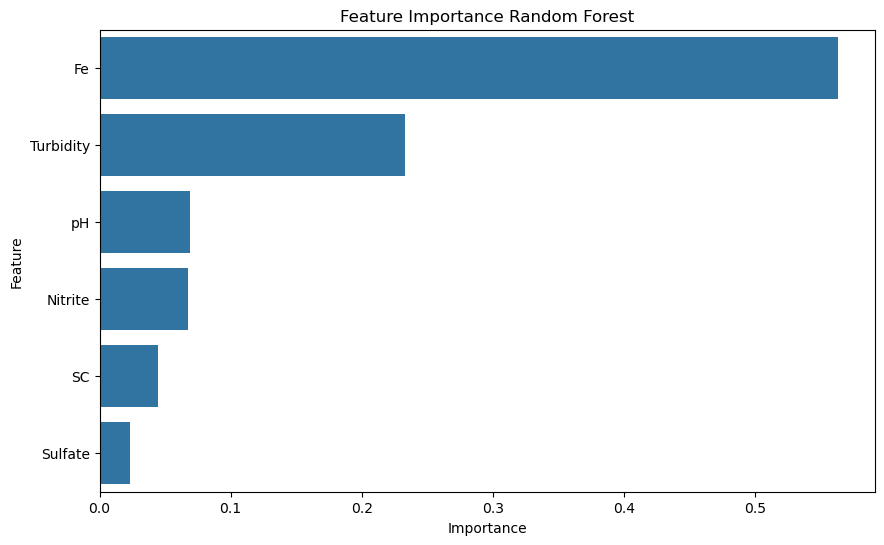

In [12]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance Random Forest")
plt.show()

In [13]:
# ============================================================
# SAVE MODEL
# ============================================================
joblib.dump(rf, "Randomforest_baru.pkl")

print("\nModel berhasil disimpan sebagai:")
print("Randomforest_cw.pkl")


Model berhasil disimpan sebagai:
Randomforest_cw.pkl
